# CT-JEPA Data Preprocessing

Two-stage pipeline:
1. **Full volumes** — all 1018 patients, resampled to 1 mm isotropic, saved as `.npz` for JEPA pretraining  
2. **Nodule patches** — 96×96×96 crops centered on annotated nodules with soft labels for fine-tuning

**Prerequisites:**
- LIDC-IDRI DICOM files at `data.raw_dir` in `jepa_config.yaml`
- LIDC-IDRI XML annotation files (separate TCIA download) at `preprocessing.xml_dir` in config  
  If XMLs are not yet downloaded, run the pipeline anyway — full volumes will still be saved;  
  patch extraction will produce 0 patches (expected).

**Workflow:** Run TEST MODE (5 patients) first. Verify shapes and errors. Then run full pipeline.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Volumes/thanu's T7/lung_cancer_vljepa/code


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.config import load_config
from src.utils.seed import set_global_seed
from src.preprocessing.preprocess import (
    build_series_to_patient,
    parse_all_xml,
    aggregate_nodules,
    run_pipeline,
)

## Load Config

In [3]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "jepa_config.yaml"
config = load_config(str(CONFIG_PATH))

set_global_seed(
    seed=config["project"]["seed"],
    deterministic=config["project"]["deterministic"],
)

RAW_DIR       = config["data"]["raw_dir"]
PROCESSED_DIR = config["data"]["processed_dir"]
XML_DIR       = (config["preprocessing"] or {}).get("xml_dir", RAW_DIR)

print("Raw DICOM dir: ", RAW_DIR)
print("Processed dir: ", PROCESSED_DIR)
print("XML dir:       ", XML_DIR)
print("Raw dir exists:", Path(RAW_DIR).exists())
print("XML dir exists:", Path(XML_DIR).exists())

# Count series folders and XML files
n_series = sum(1 for d in Path(RAW_DIR).iterdir() if d.is_dir()) if Path(RAW_DIR).exists() else 0
n_xml    = len(list(Path(XML_DIR).rglob("*.xml"))) if Path(XML_DIR).exists() else 0
print(f"Series folders: {n_series}")
print(f"XML files found: {n_xml}")

if n_xml == 0:
    print()
    print("[WARN] No XML annotation files found.")
    print("       Full volumes will be saved. Nodule patches will be skipped.")
    print("       Download the LIDC-IDRI annotation XML package from TCIA and")
    print(f"       place XMLs at: {XML_DIR}")

Setting global seed: 42
Enabling deterministic mode (may reduce performance)
Reproducibility configured successfully.
Raw DICOM dir:  /Volumes/thanu's T7/lung_cancer_vljepa/code/data/raw/LIDC-IDRI
Processed dir:  /Volumes/thanu's T7/lung_cancer_vljepa/code/data/processed
XML dir:        /Volumes/thanu's T7/lung_cancer_vljepa/code/data/raw/annotations/LIDC-XML-only
Raw dir exists: True
XML dir exists: True
Series folders: 1302
XML files found: 1319


## Step 1 — Quick Annotation Sanity Check (no DICOM loading)

In [4]:
if n_xml > 0:
    # Build series→patient map first (needed to resolve series UIDs in XMLs)
    print("Building series→patient map (reads one DICOM header per series)...")
    series_to_patient = build_series_to_patient(RAW_DIR)
    n_patients = len(set(series_to_patient.values()))
    print(f"  {len(series_to_patient)} series → {n_patients} patients")

    # Parse XMLs
    print("Parsing XML annotations...")
    raw_index = parse_all_xml(XML_DIR, series_to_patient)
    print(f"  Annotations for {len(raw_index)} patients")

    # Aggregate with soft labels
    soft_label_map = {
        int(k): float(v)
        for k, v in (config["labels"] or {}).get(
            "soft_label_map", {1: 0.0, 2: 0.1, 3: 0.5, 4: 0.9, 5: 1.0}
        ).items()
    }
    min_rad = (config["preprocessing"] or {}).get("min_radiologists", 2)
    patient_annotations = aggregate_nodules(raw_index, min_rad, soft_label_map)

    total_nodules = sum(len(v) for v in patient_annotations.values())
    score3_count  = sum(
        1 for nodules in patient_annotations.values()
        for n in nodules if 2.5 <= n["avg_score"] <= 3.5
    )

    print(f"\nAnnotation summary:")
    print(f"  Patients with valid nodules: {len(patient_annotations)}")
    print(f"  Total nodules:               {total_nodules}")
    print(f"  Score-3 (ambiguous) nodules: {score3_count}")

    # Soft label distribution
    all_soft = [n["soft_label"] for nodules in patient_annotations.values() for n in nodules]
    print(f"  Soft label mean: {np.mean(all_soft):.3f}, std: {np.std(all_soft):.3f}")
    print(f"  Soft label range: [{min(all_soft):.2f}, {max(all_soft):.2f}]")
else:
    print("Skipping annotation sanity check — no XML files.")
    patient_annotations = {}

Building series→patient map (reads one DICOM header per series)...


Building series→patient map: 100%|█████████| 1302/1302 [00:02<00:00, 501.80it/s]


  1302 series → 1010 patients
Parsing XML annotations...


Parsing XML annotations: 100%|██████████████| 1319/1319 [00:18<00:00, 73.10it/s]


  Annotations for 1010 patients

Annotation summary:
  Patients with valid nodules: 797
  Total nodules:               1885
  Score-3 (ambiguous) nodules: 1033
  Soft label mean: 0.437, std: 0.289
  Soft label range: [0.00, 1.00]


## Step 2 — TEST MODE (5 patients)

Run on 5 patients first. Check output shapes and errors. Only proceed to full pipeline if clean.

In [5]:
TEST_MODE = False   # Set False to run full pipeline
TEST_N    = 5

print(f"{'TEST MODE — ' + str(TEST_N) + ' patients' if TEST_MODE else 'FULL PIPELINE'}: starting...")

FULL PIPELINE: starting...


In [6]:
meta_df, labels_df = run_pipeline(
    config=config,
    test_mode=TEST_MODE,
    test_n=TEST_N,
)

print("\nMetadata shape:", meta_df.shape)
print("Labels shape:  ", labels_df.shape)

Step 1: Building series→patient mapping from DICOM headers...


Building series→patient map: 100%|████████| 1302/1302 [00:01<00:00, 1133.50it/s]


  1302 series → 1010 unique patients
Step 2: Parsing XML annotations from /Volumes/thanu's T7/lung_cancer_vljepa/code/data/raw/annotations/LIDC-XML-only ...


Parsing XML annotations: 100%|██████████████| 1319/1319 [00:19<00:00, 69.04it/s]


  Annotations found for 1010 patients
Step 3: Aggregating nodules (min_radiologists=2)...
  797 patients, 1885 valid nodules


Preprocessing patients:  16%|██▎           | 164/1018 [14:11<1:17:58,  5.48s/it]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x1414c6000): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.741489

Preprocessing patients:  20%|██▋           | 199/1018 [17:12<1:09:18,  5.08s/it]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x1267ffe50): Non uniform sampling or missing slices detected,  maximum nonuniformity:1.24532

Preprocessing patients:  25%|███▍          | 250/1018 [21:32<1:25:04,  6.65s/it]WARNING: In /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x1267ffe50): Non uniform sampling or missing slices detected,  maximum nonuniformity:1.97315

Preprocessin


PIPELINE SUMMARY
Patients processed:    1010
Patients/nodules skipped: 0
Nodule patches saved:  1885
Full volumes saved:    1010
Outputs → /Volumes/thanu's T7/lung_cancer_vljepa/code/data/processed

Metadata shape: (1010, 5)
Labels shape:   (1885, 13)


## Step 3 — Validate Test Outputs

In [7]:
from pathlib import Path

processed_path = Path(PROCESSED_DIR)

# --- Full volumes ---
vol_files = list((processed_path / "full_volumes").glob("*.npz")) if (processed_path / "full_volumes").exists() else []
print(f"Full volumes saved: {len(vol_files)}")

if vol_files:
    sample_vol = np.load(str(vol_files[0]))
    vol = sample_vol["volume"]
    print(f"  Sample volume shape: {vol.shape}")
    print(f"  Value range: [{float(vol.min()):.3f}, {float(vol.max()):.3f}]")
    print(f"  Dtype: {vol.dtype}")

# --- Nodule patches ---
patch_files = list((processed_path / "patches").rglob("*.npz")) if (processed_path / "patches").exists() else []
print(f"\nNodule patches saved: {len(patch_files)}")

if patch_files:
    sample_patch = np.load(str(patch_files[0]))
    patch = sample_patch["patch"]
    soft_label = float(sample_patch["soft_label"])
    avg_score  = float(sample_patch["avg_score"])
    print(f"  Sample patch shape:  {patch.shape}")
    print(f"  Expected shape:      (96, 96, 96)")
    print(f"  Shape OK:            {patch.shape == (96, 96, 96)}")
    print(f"  Value range: [{float(patch.min()):.3f}, {float(patch.max()):.3f}]")
    print(f"  Soft label: {soft_label:.3f}  (avg score: {avg_score:.2f})")
    print(f"  Dtype: {patch.dtype}")

Full volumes saved: 1010
  Sample volume shape: (344, 350, 350)
  Value range: [0.000, 1.000]
  Dtype: float16

Nodule patches saved: 1932
  Sample patch shape:  (96, 96, 96)
  Expected shape:      (96, 96, 96)
  Shape OK:            True
  Value range: [0.000, 1.000]
  Soft label: 0.100  (avg score: 2.00)
  Dtype: float16


In [8]:
# Validate ALL test patches
shape_errors = []
range_errors = []

for pf in patch_files:
    try:
        data = np.load(str(pf))
        p = data["patch"]
        if p.shape != (96, 96, 96):
            shape_errors.append((str(pf), p.shape))
        if float(p.min()) < -0.01 or float(p.max()) > 1.01:
            range_errors.append((str(pf), float(p.min()), float(p.max())))
    except Exception as e:
        shape_errors.append((str(pf), str(e)))

print(f"Patches validated: {len(patch_files)}")
print(f"Shape errors:      {len(shape_errors)}")
print(f"Range errors:      {len(range_errors)}")

if shape_errors:
    print("First shape error:", shape_errors[0])
if range_errors:
    print("First range error:", range_errors[0])

if not shape_errors and not range_errors:
    print("All patches valid.")
    if labels_df is not None and len(labels_df) > 0:
        print(f"\nSoft label distribution:")
        print(labels_df["soft_label"].describe().round(3))

Patches validated: 1932
Shape errors:      0
Range errors:      0
All patches valid.

Soft label distribution:
count    1885.000
mean        0.437
std         0.289
min         0.000
25%         0.233
50%         0.400
75%         0.633
max         1.000
Name: soft_label, dtype: float64


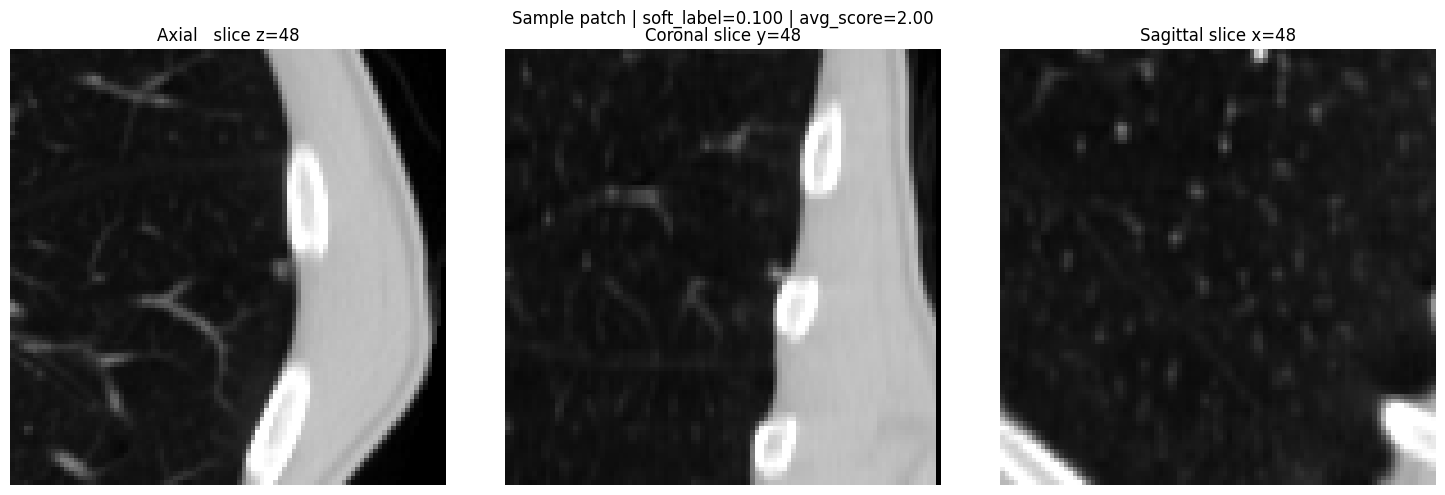

In [9]:
# Visualize a sample patch (3 orthogonal planes)
if patch_files:
    data   = np.load(str(patch_files[0]))
    vol    = data["patch"].astype(np.float32)
    slabel = float(data["soft_label"])
    ascore = float(data["avg_score"])

    z, y, x = vol.shape[0]//2, vol.shape[1]//2, vol.shape[2]//2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Sample patch | soft_label={slabel:.3f} | avg_score={ascore:.2f}")
    axes[0].imshow(vol[z, :, :], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Axial   slice z={z}")
    axes[1].imshow(vol[:, y, :], cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Coronal slice y={y}")
    axes[2].imshow(vol[:, :, x], cmap="gray", vmin=0, vmax=1)
    axes[2].set_title(f"Sagittal slice x={x}")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No patches to visualize (XML annotations not present or no annotated patients in test set).")

## Step 4 — Confirm Test Results and Run Full Pipeline

If the test run above:
- Saved expected number of full volumes (= TEST_N)
- Patches have shape `(96, 96, 96)` and values in `[0, 1]`
- No unexpected errors in `skipped_patients.csv`

Then set `TEST_MODE = False` in the cell below and run the full pipeline.

> **Note:** Full pipeline on 1018 patients (~124 GB) takes several hours on M2 MacBook Pro.
> Keep the machine plugged in and use `tqdm` progress bars to monitor.

In [10]:
# Check skipped log from test run
skipped_path = Path(PROCESSED_DIR) / "skipped_patients.csv"
if skipped_path.exists():
    skipped_df = pd.read_csv(skipped_path)
    print(f"Skipped entries: {len(skipped_df)}")
    if len(skipped_df) > 0:
        print(skipped_df.head(10).to_string())
else:
    print("No skipped_patients.csv found.")

Skipped entries: 0


In [11]:
# ============================================================
# FULL PIPELINE
# Set TEST_MODE = False only after test run looks clean.
# ============================================================

RUN_FULL_PIPELINE = False   # <-- flip to True when ready

if RUN_FULL_PIPELINE:
    print("Running FULL pipeline on all patients...")
    meta_full, labels_full = run_pipeline(
        config=config,
        test_mode=False,
    )
    print("\nFull pipeline complete.")
    print("Metadata rows: ", len(meta_full))
    print("Label rows:    ", len(labels_full))
    if len(labels_full) > 0:
        print("\nSoft label distribution:")
        print(labels_full["soft_label"].describe().round(3))
else:
    print("RUN_FULL_PIPELINE=False — skipped. Set to True when test run is clean.")

RUN_FULL_PIPELINE=False — skipped. Set to True when test run is clean.


## Step 5 — Final Stats (after full pipeline)

In [12]:
# Load saved outputs and print final statistics
labels_csv   = Path(PROCESSED_DIR) / "labels.csv"
metadata_csv = Path(PROCESSED_DIR) / "metadata.csv"

if labels_csv.exists():
    ldf = pd.read_csv(labels_csv)
    mdf = pd.read_csv(metadata_csv)

    print(f"Patients processed:     {len(mdf)}")
    print(f"Nodule patches saved:   {len(ldf)}")

    vol_count = len(list((Path(PROCESSED_DIR) / "full_volumes").glob("*.npz")))
    print(f"Full volumes saved:     {vol_count}")

    print("\nSoft label distribution:")
    print(ldf["soft_label"].value_counts(bins=5).sort_index())

    print("\nAvg score distribution:")
    print(ldf["avg_score"].value_counts(bins=5).sort_index())
else:
    print("labels.csv not found — run pipeline first.")

Patients processed:     1010
Nodule patches saved:   1885
Full volumes saved:     1010

Soft label distribution:
(-0.002, 0.2]    455
(0.2, 0.4]       534
(0.4, 0.6]       398
(0.6, 0.8]       253
(0.8, 1.0]       245
Name: count, dtype: int64

Avg score distribution:
(0.995, 1.8]    251
(1.8, 2.6]      499
(2.6, 3.4]      686
(3.4, 4.2]      292
(4.2, 5.0]      157
Name: count, dtype: int64
